<a href="https://colab.research.google.com/github/NikhilGeorge01/ML-Prac/blob/main/PCA%2CLDA%2CLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#160123737198
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/MLDatasets/house_price_train.csv')

In [34]:
#160123737198
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [36]:
#160123737198
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded = encoder.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))

df = pd.concat([df.drop(cat_cols, axis=1).reset_index(drop=True),
                encoded_df.reset_index(drop=True)], axis=1)

In [37]:
#160123737198
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [38]:
#160123737198
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [39]:
#160123737198
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
#160123737198
import numpy as np
print(np.isnan(X_scaled).sum())

0


In [42]:
#160123737198
from sklearn.decomposition import PCA

In [43]:
#160123737198
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

In [46]:
#160123737198
y_numeric = pd.factorize(y)[0]

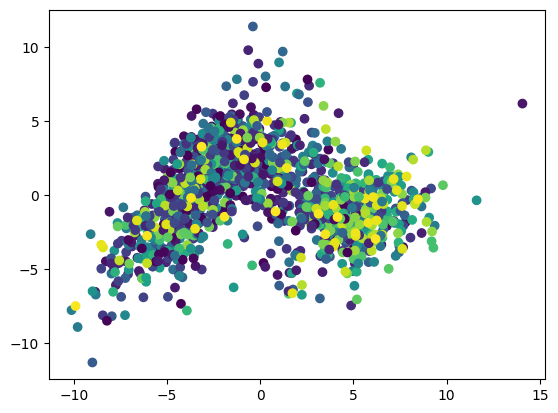

In [47]:
#160123737198
import matplotlib.pyplot as plt
plt.scatter(X_pca[:,0], X_pca[:,1], c = y_numeric)
plt.show()

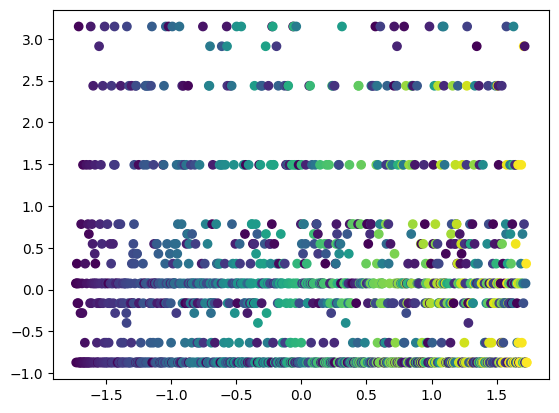

In [48]:
#160123737198
plt.scatter(X_scaled[:,0], X_scaled[:,1], c = y_numeric)
plt.show()

In [54]:
#160123737198
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multiple_linear_model = LinearRegression()
multiple_linear_model.fit(X_train, y_train)

print("--- Model Parameters ---")
print("Intercept:", multiple_linear_model.intercept_)
print("Coefficients (Slopes for each feature):", multiple_linear_model.coef_)

y_pred_multiple = multiple_linear_model.predict(X_test)

mse_multiple = mean_squared_error(y_test, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)

print("\n--- Model Evaluation Metrics ---")
print("Mean Squared Error (MSE):", mse_multiple)
print("Mean Absolute Error (MAE):", mae_multiple)
print("Root Mean Squared Error (RMSE):", rmse_multiple)

--- Model Parameters ---
Intercept: -384135.73384013015
Coefficients (Slopes for each feature): [ 5.36734470e-01  1.32956216e+01  1.17424705e+01  6.68123660e-01
  6.54819140e+03  5.80947219e+03  3.12833026e+02  1.35675553e+02
  1.80586909e+01  1.68426871e+01  6.70955158e+00 -1.45984447e+00
  2.20924945e+01  1.63979696e+01  3.27985695e+01 -2.38816922e+01
  2.53148419e+01  1.69528425e+03 -2.40461988e+03  2.91694669e+03
  2.17006861e+03 -2.61300787e+03 -1.23974497e+04  1.88077745e+03
  2.84974103e+03  1.93439844e+01  3.84886088e+02  2.63355494e+01
  1.68774715e+01  4.03915427e-02 -5.77846095e+00  4.87517172e+01
  3.25584467e+01  8.16612246e+01  1.97486313e+00 -4.44586415e+02
 -3.47771123e+02 -1.73789368e+04  1.13256866e+04  1.92806951e+03
  2.77745740e+03  1.34772330e+03 -1.11880972e+04  1.11880972e+04
 -2.41899447e+03  2.41899447e+03 -4.24538961e+03  3.34412070e+03
  3.34197591e+03 -2.44070700e+03 -3.46642446e+03  1.10963160e+04
 -9.60346814e+03  1.97357664e+03  1.67001675e+04 -1.6700167

In [55]:
#160123737198
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

median_price = df['SalePrice'].median()
df['Price_Category'] = df['SalePrice'].apply(lambda x: 1 if x > median_price else 0)

X_classification = df.drop(['SalePrice', 'Price_Category'], axis=1)
y_category = df['Price_Category']

cat_cols_classification = X_classification.select_dtypes(include=['object']).columns

if cat_cols_classification.size > 0:
    encoder_classification = OneHotEncoder(handle_unknown='ignore')
    encoded_cat_classification = encoder_classification.fit_transform(X_classification[cat_cols_classification])
    encoded_cat_df_classification = pd.DataFrame(encoded_cat_classification.toarray(),
                                                 columns=encoder_classification.get_feature_names_out(cat_cols_classification),
                                                 index=X_classification.index)
    X_classification = X_classification.drop(cat_cols_classification, axis=1)
    X_classification = pd.concat([X_classification, encoded_cat_df_classification], axis=1)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_classification, y_category, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_cls, y_train_cls)

y_pred_cls = logistic_model.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_cls)
conf_matrix = confusion_matrix(y_test_cls, y_pred_cls)
class_report = classification_report(y_test_cls, y_pred_cls)

print("Logistic Regression Model Evaluation:")
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Logistic Regression Model Evaluation:
Accuracy: 0.9315068493150684

Confusion Matrix:
 [[147  14]
 [  6 125]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.94       161
           1       0.90      0.95      0.93       131

    accuracy                           0.93       292
   macro avg       0.93      0.93      0.93       292
weighted avg       0.93      0.93      0.93       292



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
